Importing all the required libraries

In [151]:
import os
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [152]:
train = pd.read_csv('train-test.csv')
validation = pd.read_csv('validation.csv')
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


Performing EDA

In [153]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [154]:
train.shape, validation.shape

((48000, 14), (12000, 13))

In [155]:
# validation has no posted_rate column
validation.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [156]:
train.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [157]:
validation.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64

In [158]:
train.duplicated().sum()

np.int64(0)

In [159]:
train.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


Checking the weight column because the minimum is negative

In [160]:
print('negative weights in train      :', (train['weight'] < 0).sum())
print('negative weights in validation :', (validation['weight'] < 0).sum())

negative weights in train      : 292
negative weights in validation : 145


We should take the absolute value as weights cannot be negative

In [161]:
train['weight'] = train['weight'].abs()
validation['weight'] = validation['weight'].abs()

Checking the dates

In [162]:
train['date'] = pd.to_datetime(train['date'])
validation['date'] = pd.to_datetime(validation['date'])

In [163]:
print('train dates :', train['date'].min(), 'to', train['date'].max())
print('validation dates :', validation['date'].min(), 'to', validation['date'].max())

train dates : 2025-01-01 00:00:00 to 2025-10-31 00:00:00
validation dates : 2025-11-01 00:00:00 to 2025-12-31 00:00:00


There is no date overlap.

This means we are predicting the future so need to split by date.

In [164]:
# number of loads in each month
train['date'].dt.to_period('M').value_counts().sort_index()

date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, Name: count, dtype: int64

Looking at the target column

In [165]:
train['posted_rate'].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

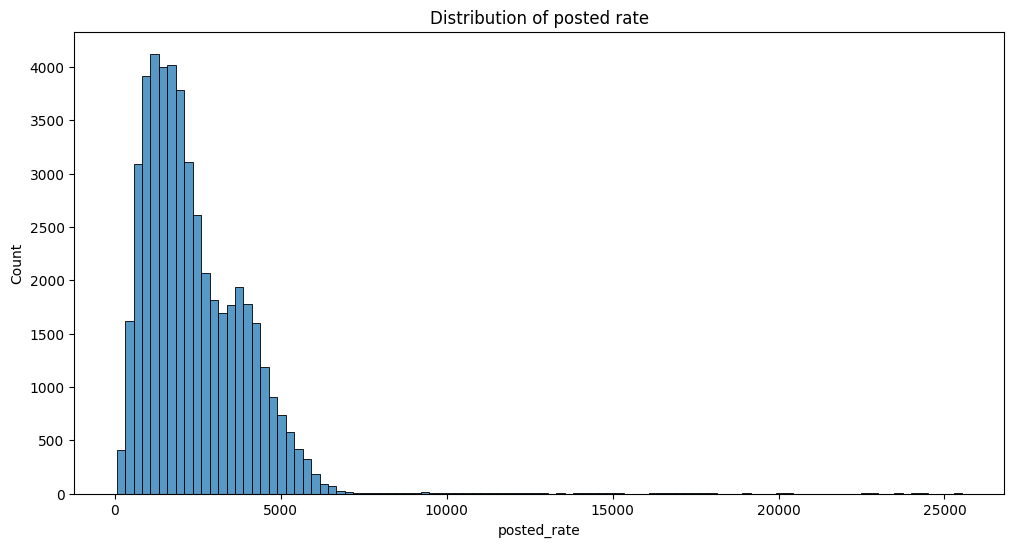

In [166]:
plt.figure(figsize=(12, 6))
sns.histplot(train['posted_rate'], bins=100)
plt.title('Distribution of posted rate')
plt.show()

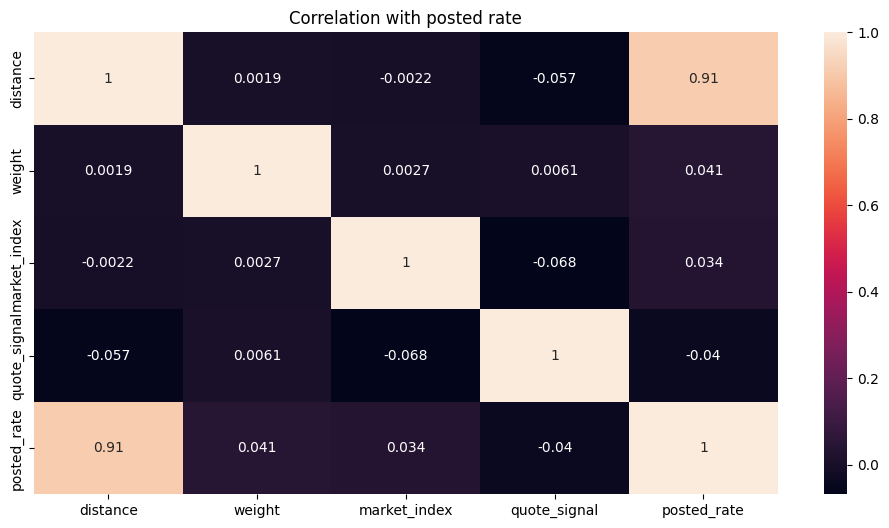

In [167]:
plt.figure(figsize=(12, 6))
sns.heatmap(train[['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']].corr(), annot=True)
plt.title('Correlation with posted rate')
plt.show()

Distance has a 0.91 correlation with the rate and hides every other signal.

In trucking the normal way to compare prices is rate per mile, so lets make that column.

In [168]:
train['rate_per_mile'] = train['posted_rate'] / train['distance']
train['rate_per_mile'].describe()

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64

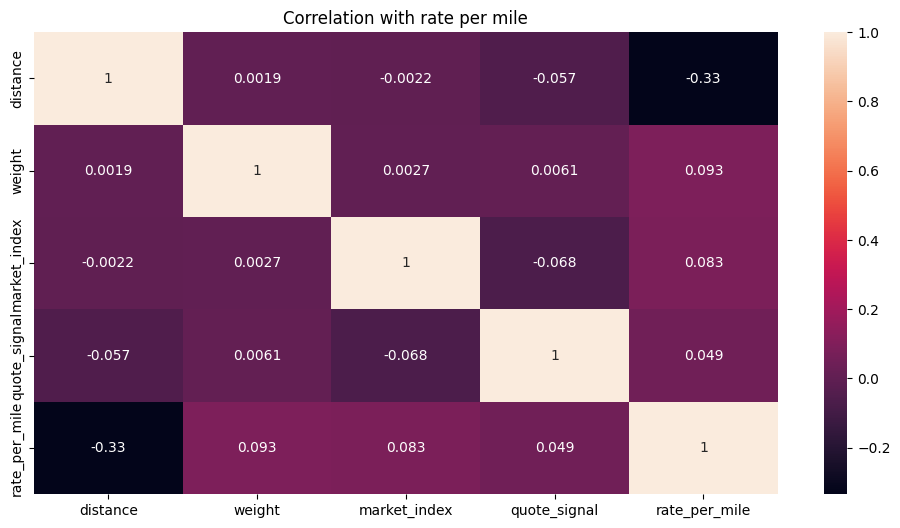

In [169]:
plt.figure(figsize=(12, 6))
sns.heatmap(train[['distance', 'weight', 'market_index', 'quote_signal', 'rate_per_mile']].corr(), annot=True)
plt.title('Correlation with rate per mile')
plt.show()

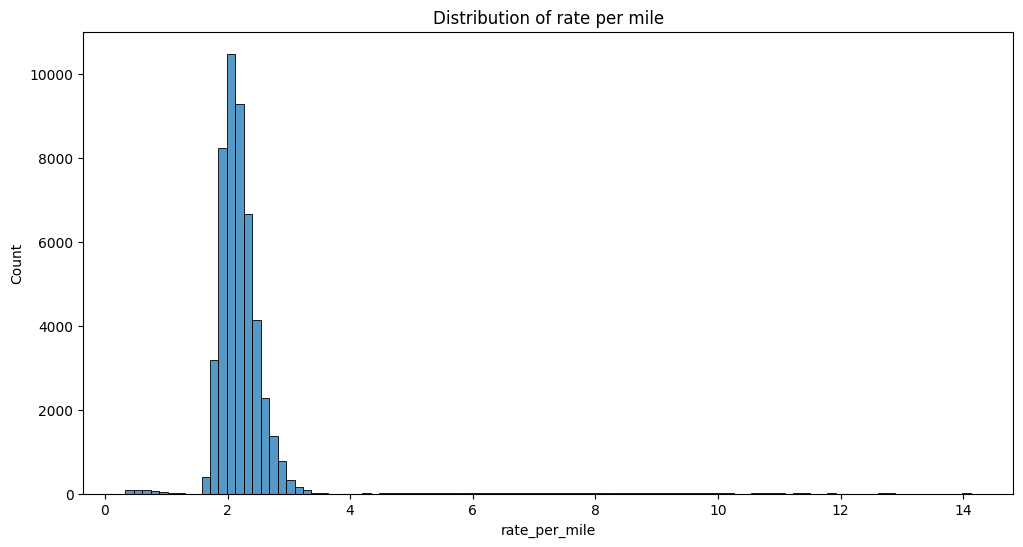

In [170]:
plt.figure(figsize=(12, 6))
sns.histplot(train['rate_per_mile'], bins=100)
plt.title('Distribution of rate per mile')
plt.show()

Most values sit around 2 but a few are very far away. Using a log scale to see them clearly.

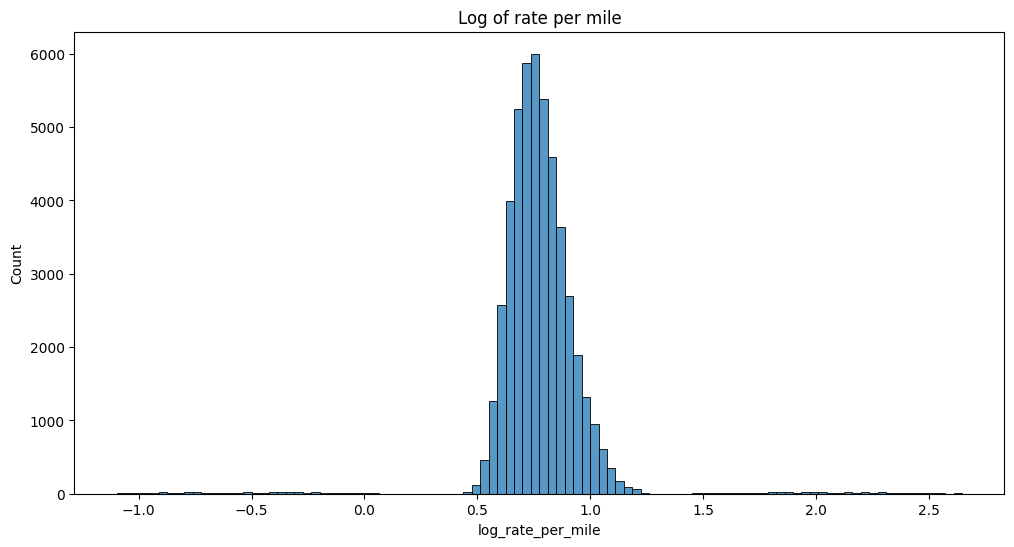

In [171]:
train['log_rate_per_mile'] = np.log(train['rate_per_mile'])
plt.figure(figsize=(12, 6))
sns.histplot(train['log_rate_per_mile'], bins=100)
plt.title('Log of rate per mile')
plt.show()

There are three separate distributions with empty gaps in between them.

Real prices would be one smooth distribution, so the two small side humps might be ignorable (bad data)

In [172]:
# counting how many rows fall in each distribution set
print('low :', (train['log_rate_per_mile'] <= 0.4).sum())
print('main :', ((train['log_rate_per_mile'] > 0.4) & (train['log_rate_per_mile'] < 1.3)).sum())
print('high :', (train['log_rate_per_mile'] >= 1.3).sum())

low : 337
main : 47323
high : 340


In [173]:
# marking the good rows
train['is_clean'] = (train['log_rate_per_mile'] > 0.4) & (train['log_rate_per_mile'] < 1.3)
train['is_clean'].value_counts()

is_clean
True     47323
False      677
Name: count, dtype: int64

In [174]:
percent_bad = (train['is_clean'] == False).sum() / train.shape[0] * 100
print('bad rows percentage :', percent_bad)

bad rows percentage : 1.4104166666666667


Checking if the bad rows are grouped in some month or equipment, or spread randomly

In [175]:
train[train['is_clean'] == False].groupby(train['date'].dt.to_period('M'))['is_clean'].value_counts()

date     is_clean
2025-01  False       81
2025-02  False       57
2025-03  False       71
2025-04  False       66
2025-05  False       62
2025-06  False       63
2025-07  False       65
2025-08  False       68
2025-09  False       64
2025-10  False       80
Name: count, dtype: int64

Dropping the outliers

In [176]:
train = train[train['is_clean']]

We fill empty values with the median of the column

In [177]:
weight_median = train['weight'].median()
market_index_median = train['market_index'].median()
print('weight median       :', weight_median)
print('market index median :', round(market_index_median, 4))

weight median       : 31508.0
market index median : 1.0559


In [178]:
train['weight'] = train['weight'].fillna(weight_median)
train['market_index'] = train['market_index'].fillna(market_index_median)

Checking the cities

In [179]:
train_cities = set(train['pickup']) | set(train['delivery'])
validation_cities = set(validation['pickup']) | set(validation['delivery'])
print('cities in train      :', len(train_cities))
print('cities in validation :', len(validation_cities))

cities in train      : 64
cities in validation : 72


In [180]:
extra_cities = validation_cities - train_cities
extra_cities

{'Allentown',
 'Charlotte',
 'Chicago',
 'Jackson',
 'Knoxville',
 'Laredo',
 'Norfolk',
 'San Diego'}

There are 8 cities in validation that are not in training data.

We should use latitude and longitude instead because those are numbers that work for any city.

#### Checking how the market index behaves over time

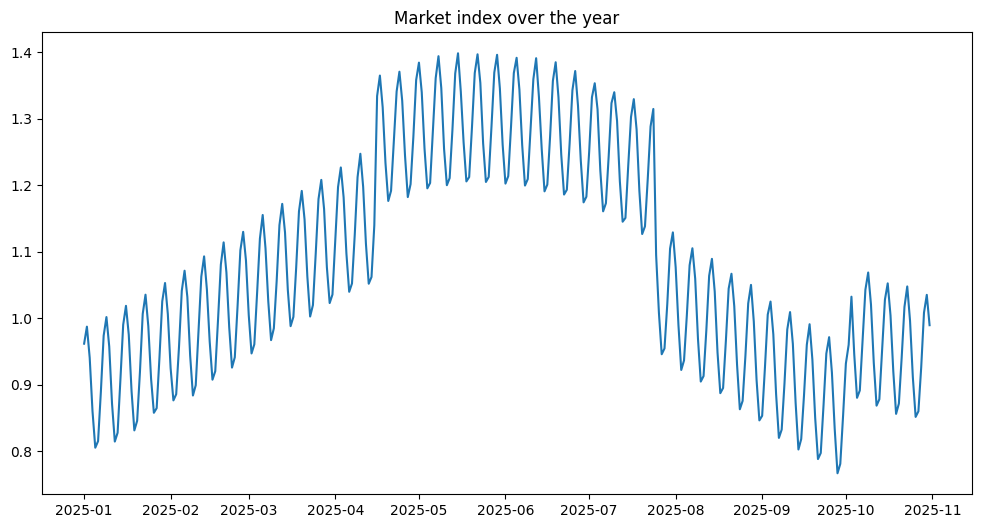

In [181]:
market_per_day = train.groupby('date')['market_index'].mean()
plt.figure(figsize=(12, 6))
plt.plot(market_per_day)
plt.title('Market index over the year')
plt.show()

Now checking if the market index actually moves the price

In [182]:
# comparing day by day instead of row by row, because single rows are noisy
daily = train.groupby('date').agg(rate_per_mile=('rate_per_mile', 'median'),
                                        market_index=('market_index', 'mean'))
daily.corr()

,rate_per_mile,market_index
rate_per_mile,1.000000,0.641445
market_index,0.641445,1.000000


Daily rate per mile and daily market index have a high correlation of 0.64, market index is the time signal

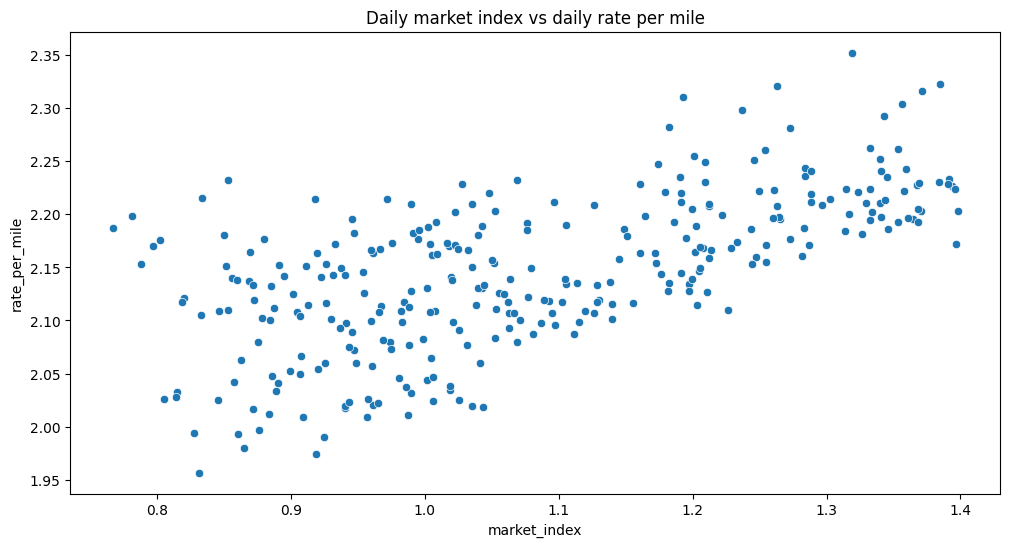

In [183]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='market_index', y='rate_per_mile', data=daily)
plt.title('Daily market index vs daily rate per mile')
plt.show()

Checking the other columns against rate per mile

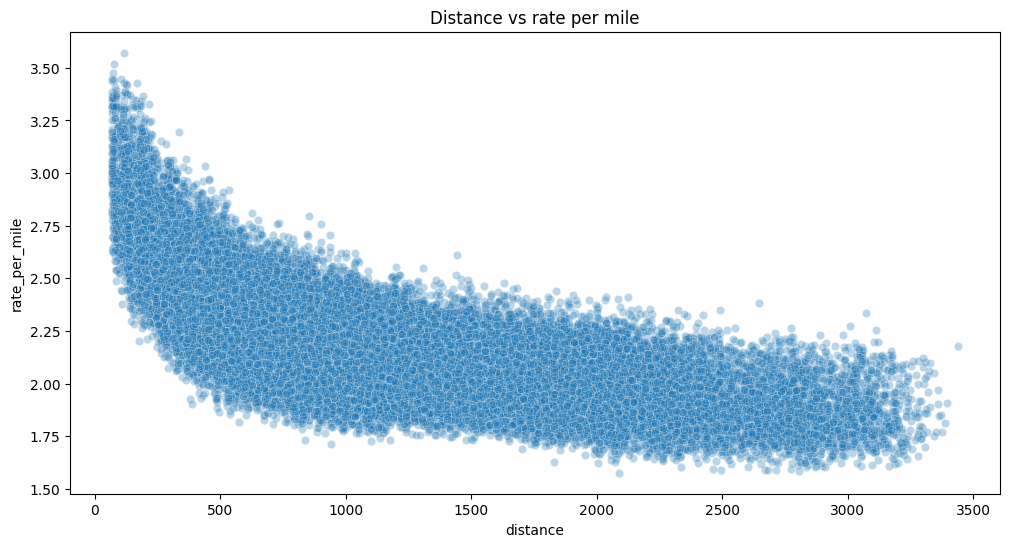

In [184]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='distance', y='rate_per_mile', data=train, alpha=0.3)
plt.title('Distance vs rate per mile')
plt.show()

In [185]:
# check equipment rate differences
train.groupby('equipment')['rate_per_mile'].mean()

equipment
Dry Van    2.086950
Flatbed    2.263132
Reefer     2.356587
Name: rate_per_mile, dtype: float64

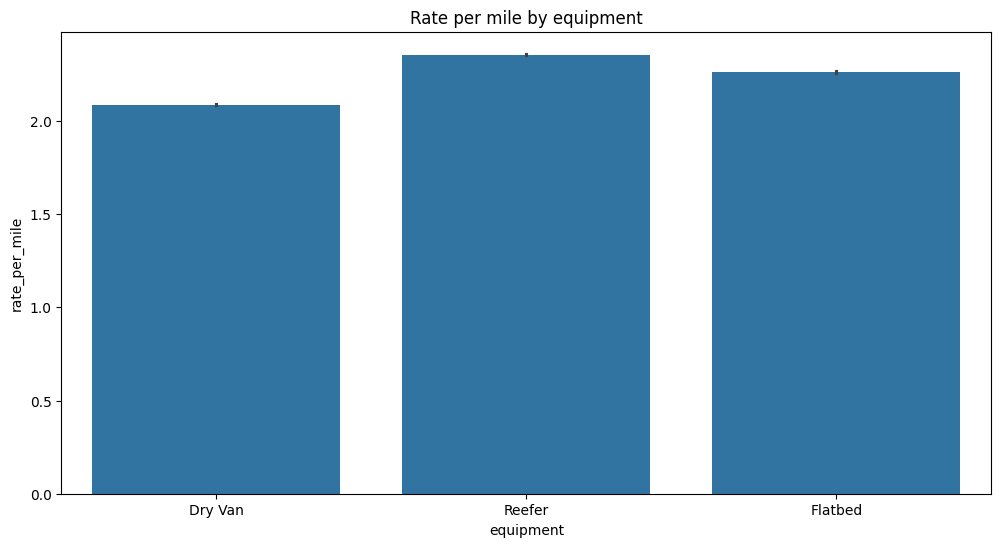

In [186]:
plt.figure(figsize=(12, 6))
sns.barplot(x='equipment', y='rate_per_mile', data=train)
plt.title('Rate per mile by equipment')
plt.show()

In [187]:
# heavier loads cost more per mile
train.groupby(pd.cut(train['weight'], [0, 15000, 25000, 32000, 40000, 50000]),
                    observed=True)['rate_per_mile'].mean()

weight
(0, 15000]        2.095486
(15000, 25000]    2.111654
(25000, 32000]    2.162699
(32000, 40000]    2.230467
(40000, 50000]    2.251285
Name: rate_per_mile, dtype: float64

In [188]:
train.groupby('pickup')['rate_per_mile'].mean().sort_values()

pickup
Reno             1.956784
San Francisco    1.994720
Albany           2.028902
Phoenix          2.035211
Fresno           2.038940
                   ...   
Louisville       2.296157
Memphis          2.303922
Atlanta          2.322471
Nashville        2.323190
Chattanooga      2.332848
Name: rate_per_mile, Length: 64, dtype: float64

In [189]:
train.groupby('delivery')['rate_per_mile'].mean().sort_values()

delivery
Reno             1.985226
San Francisco    2.009627
Albany           2.019511
Los Angeles      2.031384
Fresno           2.039832
                   ...   
Cincinnati       2.296552
Memphis          2.297803
Atlanta          2.304112
Birmingham       2.318216
Nashville        2.321250
Name: rate_per_mile, Length: 64, dtype: float64

Findings from the EDA

1. Validation is two months in the future so we must split by date, not randomly.
2. About 1.4 percent of the rows were noise, we should not use them from training.
3. Some weights are negative, we take the absolute value.
4. Validation has 8 new cities so we use latitude and longitude, not city names.
5. Distance, market index, weight, equipment and coordinates all affect the rate per mile.

Preparing the features

In [190]:
def make_features(data):
    features = pd.DataFrame()
    features['distance'] = data['distance']
    features['market_index'] = data['market_index'].fillna(market_index_median)
    features['weight'] = data['weight'].fillna(weight_median)
    features['equipment'] = data['equipment'].map({'Dry Van': 0, 'Reefer': 1, 'Flatbed': 2})
    features['pickup_lat'] = data['pickup_lat']
    features['pickup_lon'] = data['pickup_lon']
    features['delivery_lat'] = data['delivery_lat']
    features['delivery_lon'] = data['delivery_lon']
    features['quote_signal'] = data['quote_signal']
    return features

We predict rate per mile instead of the rate itself, because dividing by distance removes the distance effect.

We can multiply the prediction back by distance at the end to get the rate.

Splitting by date, we can train on the older months and test on the newest months

In [191]:
train_part = train[train['date'] < '2025-09-01']
test_part = train[train['date'] >= '2025-09-01']

X_train = make_features(train_part)
y_train = train_part['rate_per_mile']
X_test = make_features(test_part)
y_test = test_part['rate_per_mile']

print('train rows :', len(train_part))
print('test rows  :', len(test_part))

print("train set percentage: ", len(train_part) / len(train) * 100)
print("test set percentage: ", len(test_part) / len(train) * 100)

train rows : 37944
test rows  : 9379
train set percentage:  80.1808845593052
test set percentage:  19.819115440694798


Comparing a few models

In [192]:
# turns the predicted rate per mile back into a rate and returns the error in percent
def get_mape(model, features, actual_rate, distance):
    predicted_rate = model.predict(features) * distance
    return np.mean(np.abs(predicted_rate - actual_rate) / actual_rate) * 100

In [193]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=36),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=36),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=36),
    'Gradient Boosting': HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08,
                                                       max_leaf_nodes=127, random_state=36)
}

In [194]:
mape_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    mape_scores.append(get_mape(model, X_test, test_part['posted_rate'], test_part['distance']))
    print(name, 'is done')

performance = pd.DataFrame({'Model': models.keys(), 'MAPE': mape_scores}).sort_values('MAPE')
performance

Linear Regression is done
Decision Tree is done
Random Forest is done
Extra Trees is done
Gradient Boosting is done


,Model,MAPE
2,Random Forest,2.179000
3,Extra Trees,2.414594
1,Decision Tree,2.500605
4,Gradient Boosting,2.657160
0,Linear Regression,5.565837


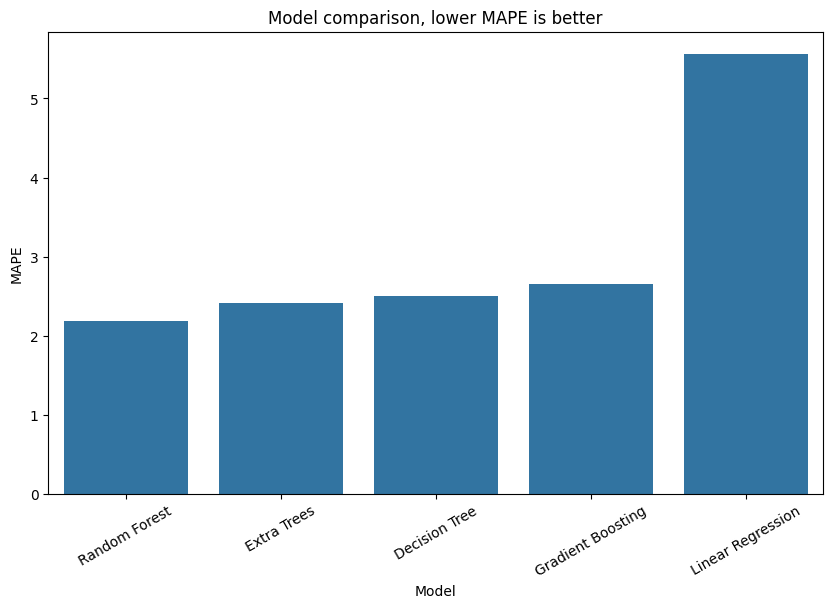

In [195]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAPE', data=performance)
plt.xticks(rotation=30)
plt.title('Model comparison, lower MAPE is better')
plt.show()

The tree models are close to each other here but this is only one split.

Now also training and checking on more than one split

Comparing the top three models on four different date splits

In [196]:
fold_results = []

for split_date in ['2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01']:
    fold_train = train[train['date'] < split_date]
    fold_test = train[train['date'] >= split_date]

    scores = {'Test from': split_date}
    for name, model in [('Random Forest', RandomForestRegressor(n_estimators=100, random_state=36)),
                        ('Extra Trees', ExtraTreesRegressor(n_estimators=200, random_state=36)),
                        ('Gradient Boosting', HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08,
                                                                            max_leaf_nodes=127, random_state=36))]:
        model.fit(make_features(fold_train), fold_train['rate_per_mile'])
        scores[name] = get_mape(model, make_features(fold_test), fold_test['posted_rate'], fold_test['distance'])

    fold_results.append(scores)

fold_table = pd.DataFrame(fold_results)
fold_table

,Test from,Random Forest,Extra Trees,Gradient Boosting
0,2025-07-01,3.541047,3.036395,3.152303
1,2025-08-01,3.528143,3.051674,3.183836
2,2025-09-01,2.182946,2.414594,2.657160
3,2025-10-01,2.572155,2.487996,2.575395


In [197]:
fold_table[['Random Forest', 'Extra Trees', 'Gradient Boosting']].mean()

Random Forest        2.956073
Extra Trees          2.747665
Gradient Boosting    2.892173
dtype: float64

Extra Trees has the lowest error on every split, so we pick Extra Trees.

Checking that dropping the bad rows was actually worth it

In [198]:
# reading the file again because train already has the bad rows removed
dirty = pd.read_csv('train-test.csv')
dirty['date'] = pd.to_datetime(dirty['date'])
dirty['weight'] = dirty['weight'].abs()
dirty = dirty[dirty['date'] < '2025-09-01']

dirty_model = ExtraTreesRegressor(n_estimators=200, random_state=36)
dirty_model.fit(make_features(dirty), dirty['posted_rate'] / dirty['distance'])

print('MAPE with bad rows    :', round(get_mape(dirty_model, X_test, test_part['posted_rate'], test_part['distance']), 2))
print('MAPE without bad rows :', round(performance['MAPE'].min(), 2))

MAPE with bad rows    : 3.77
MAPE without bad rows : 2.18


Training on the bad rows makes the error much worse, so the cleaning step was the most important one.

Trying a few sizes for the extra trees model

In [199]:
tree_counts = [50, 100, 200, 300]
tree_mapes = []

for trees in tree_counts:
    model = ExtraTreesRegressor(n_estimators=trees, random_state=36)
    model.fit(X_train, y_train)
    tree_mapes.append(get_mape(model, X_test, test_part['posted_rate'], test_part['distance']))

pd.DataFrame({'Trees': tree_counts, 'MAPE': tree_mapes})

,Trees,MAPE
0,50,2.444479
1,100,2.421725
2,200,2.414594
3,300,2.413333


The score barely changes after 200 trees.

Training the final model on all the clean data

In [200]:
final_model = ExtraTreesRegressor(n_estimators=200, random_state=36)
final_model.fit(make_features(train), train['rate_per_mile'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

Predicting the validation loads

In [201]:
validation_predicted = final_model.predict(make_features(validation)) * validation['distance']
validation_predicted.describe()

count    12000.000000
mean      2323.991000
std       1344.976611
min        184.694699
25%       1254.347534
50%       2004.057739
75%       3308.426091
max       6723.437422
Name: distance, dtype: float64

In [202]:
# the scorer rejects zero or negative rates so checking that
(validation_predicted <= 0).sum()

np.int64(0)

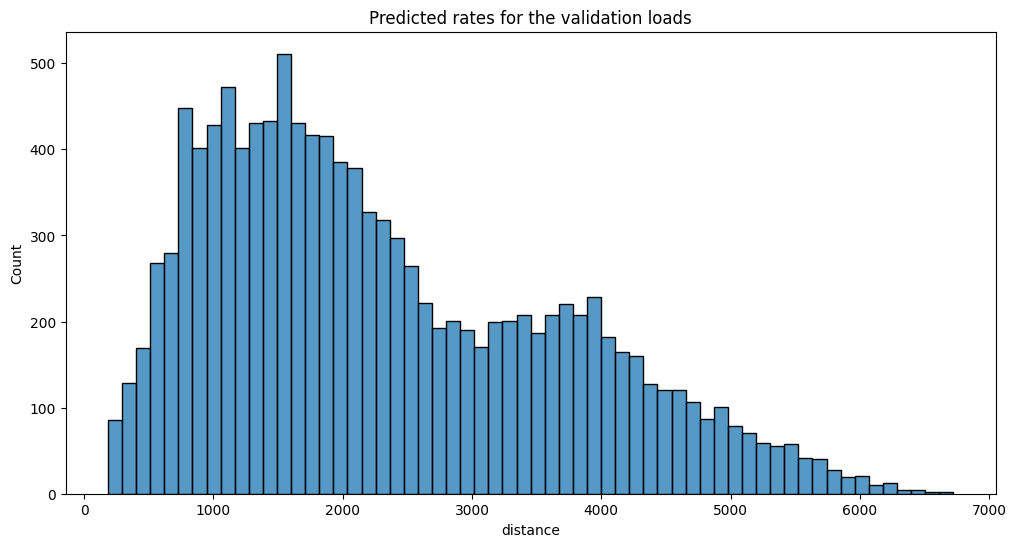

In [203]:
plt.figure(figsize=(12, 6))
sns.histplot(validation_predicted, bins=60)
plt.title('Predicted rates for the validation loads')
plt.show()

In [204]:
predictions = pd.DataFrame({'load_id': validation['load_id'], 'predicted_rate': validation_predicted.round(2)})
predictions.head()

,load_id,predicted_rate
0,TE-000001,826.57
1,TE-000002,4876.47
2,TE-000003,5176.07
3,TE-000004,4056.94
4,TE-000005,1784.43


In [205]:
predictions.to_csv('validation_predictions.csv', index=False)
predictions.shape

(12000, 2)

For December chart, every input is fixed and only the date changes

In [206]:
december = pd.read_csv('december-chart-inputs.csv')
december['date'] = pd.to_datetime(december['date'])
december.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,784.66
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,787.54
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,794.57
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,796.71
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,793.19


The december file has no market_index column, but the market index is the only time feature.

The validation file already covers December, so we can take the daily average from there.

In [207]:
market_by_date = validation.groupby('date')['market_index'].mean()
december['market_index'] = december['date'].map(market_by_date)
december['market_index'].isnull().sum()

np.int64(0)

In [208]:
# the december file has no coordinates so taking them from the training data
lexington = train[train['pickup'] == 'Lexington'][['pickup_lat', 'pickup_lon']].iloc[0]
fort_wayne = train[train['delivery'] == 'Fort Wayne'][['delivery_lat', 'delivery_lon']].iloc[0]
lexington, fort_wayne

(pickup_lat    36.99152
 pickup_lon   -84.99876
 Name: 28, dtype: float64,
 delivery_lat    41.31561
 delivery_lon   -85.36206
 Name: 24, dtype: float64)

In [209]:
december['pickup_lat'] = lexington['pickup_lat']
december['pickup_lon'] = lexington['pickup_lon']
december['delivery_lat'] = fort_wayne['delivery_lat']
december['delivery_lon'] = fort_wayne['delivery_lon']

In [210]:
# quote_signal is not given either to using the training average
december['quote_signal'] = train['quote_signal'].mean()

In [211]:
december['predicted_rate'] = (final_model.predict(make_features(december)) *
                              december['distance']).round(2)
december[['date', 'market_index', 'predicted_rate']]

,date,market_index,predicted_rate
0,2025-12-01,0.834919,783.03
1,2025-12-02,0.914680,786.38
2,2025-12-03,0.994063,793.76
3,2025-12-04,1.024021,796.03
4,2025-12-05,0.975120,792.67
5,2025-12-06,0.889154,785.40
6,2025-12-07,0.830590,782.50
7,2025-12-08,0.840110,783.00
8,2025-12-09,0.917263,786.53
9,2025-12-10,0.998907,794.09


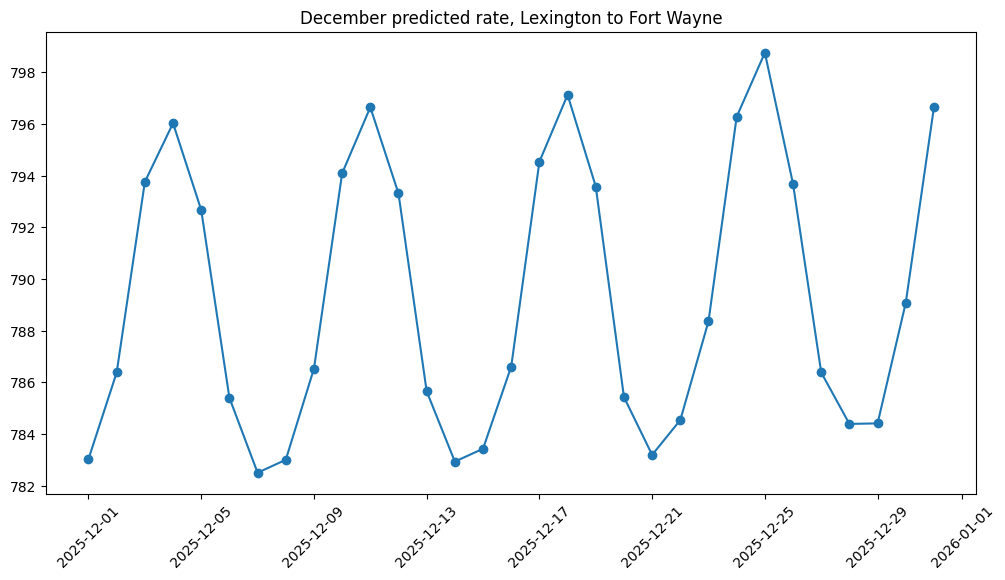

In [217]:
plt.figure(figsize=(12, 6))
plt.plot(december['date'], december['predicted_rate'], marker='o')
plt.title('December predicted rate, Lexington to Fort Wayne')
plt.xticks(rotation=45)
plt.show()

The line goes up and down every week, which matches the weekly pattern found in the market index.

Date is the only thing changing in 31 rows.

In [213]:
# dropping the new columns added
original_columns = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
december_to_save = december[original_columns].copy()
december_to_save['date'] = december_to_save['date'].dt.strftime('%Y-%m-%d')
december_to_save.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,783.03
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,786.38
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,793.76
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,796.03
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,792.67


In [214]:
december_to_save.to_csv('december-chart-inputs.csv', index=False)
december_to_save.shape

(31, 7)

Both files are saved now, so we can run the scorer

python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv

Saving the model so we can use it later without training again

In [215]:
os.makedirs('model', exist_ok=True)
pickle.dump(final_model, open('model/model.pkl', 'wb'))

In [216]:
# checking the saved model gives the same predictions
saved_model = pickle.load(open('model/model.pkl', 'rb'))
saved_predicted = saved_model.predict(make_features(december)) * december['distance']

print('same predictions :', np.allclose(saved_predicted, december['predicted_rate'], atol=0.01))

same predictions : True
